# Transformer Model - on textual embeddings 128
This notebook follows the same data-loading and split logic used by the embedding-based KNN and XGBoost notebooks, but trains `PairEmbeddingTransformerModel`, a `BaseModel` implementation defined in `utils/model_classes.py`.

The model logic is kept in the shared class; the notebook focuses on loading data, configuring the run, training, evaluating, saving, and optionally reloading the checkpoint.


In [4]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path().resolve().parent.parent.parent
print(f"Project root: {PROJECT_ROOT}")
PATH_DATA = PROJECT_ROOT / 'data' / 'exploded_splits'
print(f"Data: {PATH_DATA}")

TEXTUAL_EMBEDDING_PATH = PROJECT_ROOT / 'data' / 'textual_features'
MODEL_SAVE_PATH = PROJECT_ROOT / 'Models'
text_emb_128 = TEXTUAL_EMBEDDING_PATH / 'textual_embeddings_128.parquet'

RANDOM_STATE = 42

from utils.embedding_transformer_utils import (
    get_torch_device,
    load_pair_embedding_transformer_model,
    sample_dataframe,
    set_torch_seed,
)
from utils.model_classes import PairEmbeddingTransformerModel

RANDOM_STATE = 42
DEVICE = get_torch_device()

print(f"Project root: {PROJECT_ROOT}")
print(f"Embeddings: {text_emb_128}")
print(f"Device: {DEVICE}")

Project root: C:\Users\Tommaso\Documents\MEGAR2D2\Documenti\SUPSI\BACHELOR\3_anno_bech\primaverile\M-P6203E-DataProjects-Hackaton3_P1
Data: C:\Users\Tommaso\Documents\MEGAR2D2\Documenti\SUPSI\BACHELOR\3_anno_bech\primaverile\M-P6203E-DataProjects-Hackaton3_P1\data\exploded_splits
Project root: C:\Users\Tommaso\Documents\MEGAR2D2\Documenti\SUPSI\BACHELOR\3_anno_bech\primaverile\M-P6203E-DataProjects-Hackaton3_P1
Embeddings: C:\Users\Tommaso\Documents\MEGAR2D2\Documenti\SUPSI\BACHELOR\3_anno_bech\primaverile\M-P6203E-DataProjects-Hackaton3_P1\data\textual_features\textual_embeddings_128.parquet
Device: cuda


## 1. Load embedding data

In [5]:
df = pd.read_parquet(text_emb_128)
display(df.head())
print(df.shape)

,split,article_id,ref_id,is_reference_valid,article_emb_000,article_emb_001,article_emb_002,article_emb_003,article_emb_004,article_emb_005,...,ref_emb_118,ref_emb_119,ref_emb_120,ref_emb_121,ref_emb_122,ref_emb_123,ref_emb_124,ref_emb_125,ref_emb_126,ref_emb_127
0,train,53e99f0ab7602d97027d6a89,53e99ff0b7602d97028d14d3,1,0.256074,-0.008567,0.029547,0.027875,-0.039097,0.061652,...,0.064212,0.001819,0.028266,0.074405,-0.012687,-0.012413,-0.018658,0.019843,-0.018603,-0.062412
1,train,53e9bd81b7602d9704a24d06,557f4d4f6fee0fe990cb035f,1,0.177240,0.009653,-0.006376,0.139197,0.036759,0.024399,...,-0.002640,0.002758,-0.021711,0.000173,0.036031,0.010025,-0.032560,-0.004902,0.012356,-0.037394
2,train,539087fe20f70186a0d75db6,539087ae20f70186a0d4cf5a,1,0.279532,-0.065988,0.088996,-0.124474,0.029969,-0.064352,...,-0.025537,0.005557,0.027970,0.036103,0.017138,-0.040106,0.029802,-0.020301,-0.001983,-0.039484
3,train,539087fe20f70186a0d75db6,5390878e20f70186a0d3a260,1,0.279532,-0.065988,0.088996,-0.124474,0.029969,-0.064352,...,0.022904,0.030194,0.019120,-0.022178,-0.037727,0.054251,-0.055143,0.056518,-0.040537,-0.131712
4,train,539087fe20f70186a0d75db6,539087cb20f70186a0d58fe1,1,0.279532,-0.065988,0.088996,-0.124474,0.029969,-0.064352,...,-0.028705,-0.019178,-0.046387,-0.040602,0.018601,0.018564,0.042588,0.064933,0.001457,0.016216


(2950135, 260)


In [6]:
# Stesso split usato nei notebook KNN/XGB.
split_series = df["split"].astype(str).str.lower()
df_train = df[split_series == "train"].copy()
df_val = df[split_series.isin(["validation", "val"])].copy()
df_test = df[split_series == "test"].copy()

ID_COLUMNS = ["article_id", "ref_id"]
df_train = df_train.drop(columns=ID_COLUMNS, errors="ignore")
df_val = df_val.drop(columns=ID_COLUMNS, errors="ignore")
df_test = df_test.drop(columns=ID_COLUMNS, errors="ignore")

print("Split sizes:", {"train": len(df_train), "val": len(df_val), "test": len(df_test)})

Split sizes: {'train': 2162513, 'val': 391242, 'test': 396380}


## 2. Transformer baseline model
As in the KNN notebook, this section defines the model configuration and the working dataset. Sample limits are useful for fast trial runs; set them to `None` to train on the full splits.


In [7]:
set_torch_seed(RANDOM_STATE)

MAX_TRAIN_SAMPLES = len(df_train)
MAX_VAL_SAMPLES = len(df_val)
MAX_TEST_SAMPLES = len(df_test)

TRAINING_PARAMS = {
    "epochs": 15,
    "batch_size": 512,
    "learning_rate": 1e-4,
    "weight_decay": 1e-5,
    "patience": 2,
}

MODEL_PARAMS = {
    "embedding_dim": 128,
    "d_model": 128,
    "nhead": 8,
    "num_layers": 2,
    "dim_feedforward": 256,
    "dropout": 0.15,
}

# Campionamento solo per velocizzare gli esperimenti: non cambia il formato dati.
df_train_model = sample_dataframe(df_train, MAX_TRAIN_SAMPLES, RANDOM_STATE)
df_val_model = sample_dataframe(df_val, MAX_VAL_SAMPLES, RANDOM_STATE)
df_test_model = sample_dataframe(df_test, MAX_TEST_SAMPLES, RANDOM_STATE)

print("Model split sizes:", {"train": len(df_train_model), "val": len(df_val_model), "test": len(df_test_model)})

Model split sizes: {'train': 2162513, 'val': 391242, 'test': 396380}


In [8]:
# Classe definita in utils/model_classes.py e derivata da BaseModel.
transformer_model = PairEmbeddingTransformerModel(
    model_name="pair_embedding_transformer_128",
    device=DEVICE,
    **MODEL_PARAMS,
)

print(transformer_model.model)
print("Trainable parameters:", sum(p.numel() for p in transformer_model.model.parameters() if p.requires_grad))

c:\Users\Tommaso\miniconda3\envs\hack_03\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


PairEmbeddingTransformer(
  (input_projection): Linear(in_features=128, out_features=128, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.15, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.15, inplace=False)
        (dropout2): Dropout(p=0.15, inplace=False)
      )
    )
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (classifier): Sequential(
    (0): Dropout(p=0.15, inplace=False)
    (1): Linear(in_features=128, out_features=64, bias=True

[pair_embedding_transformer_128] Preprocessing data...
Label distribution:
1.0    0.500002
0.0    0.499998
Name: proportion, dtype: float64
[pair_embedding_transformer_128] Preprocessing data...
[pair_embedding_transformer_128] Starting training...


epoch 1 train:   0%|          | 0/4224 [00:00<?, ?it/s]

predict:   0%|          | 0/765 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.41627099391045785, 'val_f1_weighted': 0.85464367313085}


epoch 2 train:   0%|          | 0/4224 [00:00<?, ?it/s]

...

epoch 15 train:   0%|          | 0/4224 [00:00<?, ?it/s]

predict:   0%|          | 0/765 [00:00<?, ?it/s]

{'epoch': 15, 'train_loss': 0.21808461657725753, 'val_f1_weighted': 0.8973999827949133}


predict:   0%|          | 0/4224 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0     0.9324    0.9178    0.9250   1081253
           1     0.9190    0.9334    0.9262   1081260

    accuracy                         0.9256   2162513
   macro avg     0.9257    0.9256    0.9256   2162513
weighted avg     0.9257    0.9256    0.9256   2162513



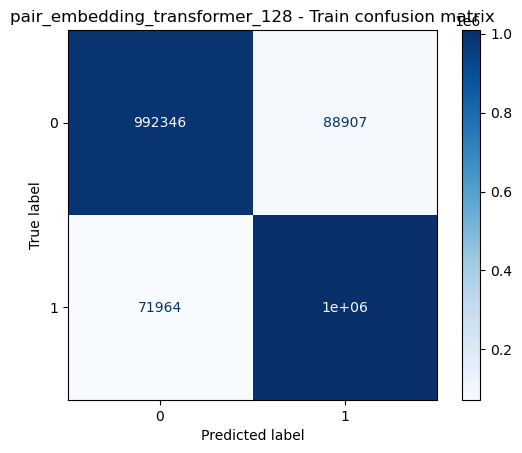

In [9]:
# Train pipeline in stile KNNModel:
# 1. preprocess train con fit dello scaler
# 2. preprocess validation con lo stesso scaler
# 3. training PyTorch
# 4. valutazione sul train
train_metrics = transformer_model.train_pipeline(
    df_train_model,
    raw_val=df_val_model,
    **TRAINING_PARAMS,
)

The transformer model that uses the 128-dimensional textual features achieves an accuracy of 92.56% on the validation set. The confusion matrix shows that the the model reach some kind of balance between the two categories and errors, predicting both valid and invalid citations corretcly 92% of the time.

,epoch,train_loss,val_f1_weighted
0,1,0.416271,0.854644
1,2,0.318347,0.870206
2,3,0.290609,0.878422
3,4,0.274077,0.883044
4,5,0.262807,0.886339
5,6,0.254112,0.889209
6,7,0.247208,0.891239
7,8,0.241601,0.893222
8,9,0.236566,0.893655
9,10,0.232598,0.895059


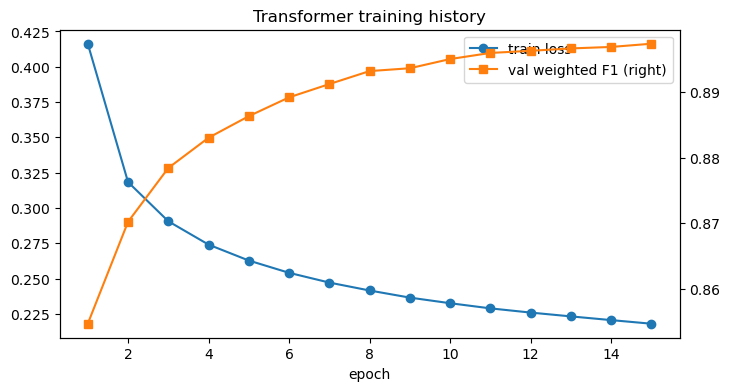

In [10]:
history_df = pd.DataFrame(transformer_model.history)
display(history_df)

if len(history_df) > 0:
    ax = history_df.plot(x="epoch", y="train_loss", marker="o", figsize=(8, 4), label="train loss")
    if "val_f1_weighted" in history_df.columns:
        history_df.plot(x="epoch", y="val_f1_weighted", marker="s", secondary_y=True, ax=ax, label="val weighted F1")
    plt.title("Transformer training history")
    plt.show()

From the training plot, we can notice how already at the start of the training loop, the model start with almost 85% of accuracy. This show how the baseline of the transformer model can reach such high performance from the textual features. The loss have a similar pattern, it start from 0.425 and decrease up to 0.2 after 15 epochs.

## 3. Final model evaluation
After training, the same model is evaluated on the test split with `test_pipeline`, using the scaler and feature columns learned from the training split.


[pair_embedding_transformer_128] Preprocessing data...
Label distribution:
1.0    0.500003
0.0    0.499997
Name: proportion, dtype: float64


predict:   0%|          | 0/775 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0     0.8705    0.8501    0.8602    198189
           1     0.8535    0.8735    0.8634    198191

    accuracy                         0.8618    396380
   macro avg     0.8620    0.8618    0.8618    396380
weighted avg     0.8620    0.8618    0.8618    396380



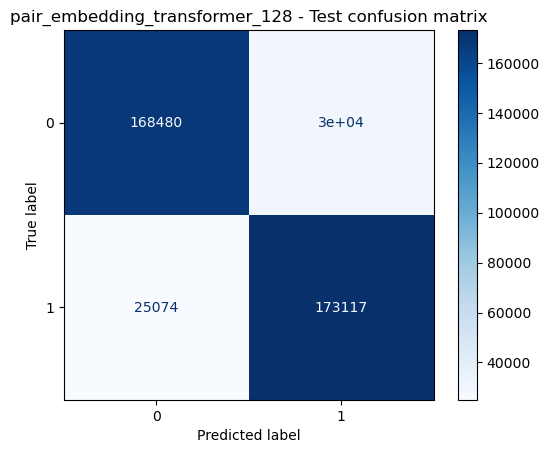

In [11]:
test_metrics = transformer_model.test_pipeline(
    df_test_model,
    batch_size=TRAINING_PARAMS["batch_size"],
)

The model performances over the unseen data (test set) reach 86.18% of accuracy, with similar number of true labels predictions. The models seems to have some more difficulty in identifying true negatives, correctly classifying 85% of the time.

## 4. Save the pretrained model
The PyTorch checkpoint is saved under `MODELZOO/textual_embeddings_128/`, together with the scaler, selected feature columns, threshold, training history, and metadata needed for inference.


In [12]:
summary = {
    "train_metrics": train_metrics,
    "test_metrics": test_metrics,
    "train_size": int(len(df_train_model)),
    "val_size": int(len(df_val_model)),
    "test_size": int(len(df_test_model)),
    "training_params": TRAINING_PARAMS,
    "history": transformer_model.history,
}


In [13]:
from utils.model_saver import save_model_artifact

save_model_artifact(transformer_model, df_name=text_emb_128.name, 
                    model_name="Best_Transformer_textual_128", 
                    relative_model_dir=MODEL_SAVE_PATH)

## 5. Load checkpoint for inference
This optional cell reloads a saved checkpoint so the model can be reused without retraining.


In [ ]:
# loaded_model = load_pair_embedding_transformer_model(
#     Path("Models/embeddings/pair_embedding_transformer_128/<checkpoint>.pt"),
#     device=DEVICE,
# )